In [1]:
import random
import time
import json
import datetime
import matplotlib.pyplot as plt

In [2]:
# Sensor reading
def read_sensor_data(worker_id):
    return {
        'worker_id' : worker_id,
        'timestamp' : datetime.datetime.now().isoformat(),
        'heart_rate_bpm': random.randint(55, 105),
        'spo2_percent': random.randint(93, 100),
        'motion_score': round(random.uniform(0, 10), 2),
        'temperature_c': round(random.uniform(20, 38), 1),
        'eye_blink_rate': random.randint(8, 30),
    }

print('Sample sensor reading:')
sample = read_sensor_data('W001')
for key, val in sample.items():
    print(f'   {key:<20} : {val}')

Sample sensor reading:
   worker_id            : W001
   timestamp            : 2026-04-20T04:18:16.236256
   heart_rate_bpm       : 86
   spo2_percent         : 97
   motion_score         : 2.9
   temperature_c        : 35.0
   eye_blink_rate       : 24


In [3]:
# AI classification
class FatigueDetector:
    THRESHOLDS = {
        'heart_rate_low': 60,
        'heart_rate_high': 95,
        'spo2_min': 95,
        'motion_min': 2.5,
        'blink_rate_low': 12,
    }
    LABELS = {0:'Normal', 1:'Mild Fatigue', 2:'Severe Fatigue'}

    def classify(self, sensor_data):
        fatigue_score = 0
        hr = sensor_data['heart_rate_bpm']
        sp = sensor_data['spo2_percent']
        mot = sensor_data['motion_score']
        blk = sensor_data['eye_blink_rate']

        if hr < self.THRESHOLDS['heart_rate_low']:fatigue_score += 2
        elif hr > self.THRESHOLDS['heart_rate_high']:fatigue_score += 1
        if sp  < self.THRESHOLDS['spo2_min']:fatigue_score += 2
        if mot < self.THRESHOLDS['motion_min']:fatigue_score += 2
        if blk < self.THRESHOLDS['blink_rate_low']:fatigue_score += 1

        level = 2 if fatigue_score >= 5 else 1 if fatigue_score >= 2 else 0
        confidence = round(min(0.5 + fatigue_score * 0.08, 0.98), 2)
        return {
            'worker_id': sensor_data['worker_id'],
            'timestamp': sensor_data['timestamp'],
            'fatigue_score': fatigue_score,
            'fatigue_level': level,
            'fatigue_label': self.LABELS[level],
            'confidence': confidence,
        }

In [4]:
detector = FatigueDetector()
print('AI classification Test:')
test_cases = [
    {'worker_id':'W_TEST', 'heart_rate_bpm':75, 'spo2_percent':98, 'motion_score':6.0, 'eye_blink_rate':18, 'timestamp': ''},
    {'worker_id':'W_TEST', 'heart_rate_bpm':58, 'spo2_percent':97, 'motion_score':1.5, 'eye_blink_rate':7, 'timestamp': ''},
    {'worker_id':'W_TEST', 'heart_rate_bpm':55, 'spo2_percent':93, 'motion_score':1.0, 'eye_blink_rate':8,  'timestamp': ''},
]
labels = ['Normal','Mild Fatigue','Severe Fatigue']
for i, tc in enumerate(test_cases):
    result = detector.classify(tc)
    print(f'  Test {i+1}: {labels[result["fatigue_level"]]} , Score: {result["fatigue_score"]} , Confidence: {result["confidence"]}')

AI classification Test:
  Test 1: Normal , Score: 0 , Confidence: 0.5
  Test 2: Severe Fatigue , Score: 5 , Confidence: 0.9
  Test 3: Severe Fatigue , Score: 7 , Confidence: 0.98


In [5]:
# SAP actions
sap_log = []
sap_log.clear()
def sap_action(module, tcode, action, details):
    entry = {
        "time": datetime.datetime.now().strftime('%H:%M:%S'),
        "module": module,
        "t_code": tcode,
        "action": action,
        "details": details,
        "status": "SIMULATED_Success"
    }
    sap_log.append(entry)
    

def handle_sap(result, worker_id):
    label = result["fatigue_label"]
    if label == "Mild Fatigue":
        sap_action("PP",    "CR02", "Reduce Work Center Capacity",  f"Worker {worker_id} -25%")
        sap_action("PP/PM", "IW21", "Log Downtime Notification",    f"Worker {worker_id}")
        sap_action("MM",    "MB21", "Update Inventory Reservation", f"Worker {worker_id}")

    elif label == "Severe Fatigue":
        sap_action("PP",    "CO02",  "Reschedule Production Order",  f"Worker {worker_id} +3hrs")
        sap_action("PP",    "CM21",  "Trigger Capacity Leveling",    "KIIT_PLANT_1000")
        sap_action("PP/PM", "IW21",  "Log Downtime Notification",    f"Worker {worker_id}")
        sap_action("MM",    "MD01",  "Re-run MRP",                   "KIIT_PLANT_1000")
        sap_action("MM",    "ME51N", "Create Purchase Requisition",  "MAT-001")
        sap_action("MM",    "MB21",  "Update Inventory Reservation", f"Worker {worker_id}")
        sap_action("MM",    "MIGO",  "Goods Movement Adjustment",    "Qty adjusted")

In [11]:
workers = ["W001", "W002", "W003"]
detector = FatigueDetector()
fatigue_counts = {"Normal": 0, "Mild Fatigue": 0, "Severe Fatigue": 0}

print("LetharSense: worker Fatigue Monitor")

for cycle in range(1, 3):
    print(f"\nRound {cycle}\n")
    for wid in workers:
        data   = read_sensor_data(wid)
        result = detector.classify(data)
        label  = result['fatigue_label']
        score  = result['fatigue_score']

        if label == "Normal":
            icon = "OK"
        elif label == "Mild Fatigue":
            icon = "WARNING"
        else:
            icon = "CRITICAL"

        print(f"Worker : {wid}")
        print(f"Health : HR={data['heart_rate_bpm']} | SpO2={data['spo2_percent']}% | Motion={data['motion_score']}")
        print(f"Result : [{icon}] {label} (score {score})")

        if label == "Normal":
            print("SAP    : No action needed\n")
        elif label == "Mild Fatigue":
            print("SAP    : Action needed")
            print("SAP PP : Reduced work center capacity (CR02)")
            print("SAP MM : Updated inventory reservation (MB21)\n")
        elif label == "Severe Fatigue":
            print("SAP    : Action needed")
            print("SAP PP : Production order rescheduled (CO02)")
            print("SAP MM : MRP rerun + purchase order raised (MD01, ME51N)\n")
        fatigue_counts[label] += 1
        handle_sap(result, wid)
    

LetharSense: worker Fatigue Monitor

Round 1

Worker : W001
Health : HR=57 | SpO2=93% | Motion=0.7
Result : [CRITICAL] Severe Fatigue (score 6)
SAP    : Action needed
SAP PP : Production order rescheduled (CO02)
SAP MM : MRP rerun + purchase order raised (MD01, ME51N)

Worker : W002
Health : HR=102 | SpO2=98% | Motion=9.84
Result : [OK] Normal (score 1)
SAP    : No action needed

Worker : W003
Health : HR=95 | SpO2=98% | Motion=7.98
Result : [OK] Normal (score 1)
SAP    : No action needed


Round 2

Worker : W001
Health : HR=88 | SpO2=93% | Motion=5.5
Result : [WARNING] Mild Fatigue (score 2)
SAP    : Action needed
SAP PP : Reduced work center capacity (CR02)
SAP MM : Updated inventory reservation (MB21)

Worker : W002
Health : HR=74 | SpO2=99% | Motion=9.96
Result : [OK] Normal (score 0)
SAP    : No action needed

Worker : W003
Health : HR=56 | SpO2=94% | Motion=8.44
Result : [WARNING] Mild Fatigue (score 4)
SAP    : Action needed
SAP PP : Reduced work center capacity (CR02)
SAP MM : 

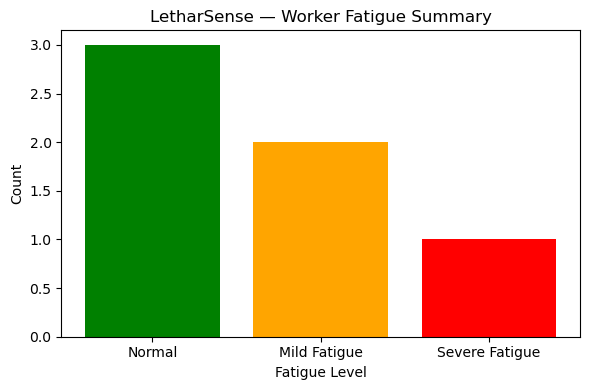

In [12]:
# Graph
colors = ["green", "orange", "red"]
plt.figure(figsize=(6, 4))
plt.bar(fatigue_counts.keys(), fatigue_counts.values(), color=colors)
plt.title("LetharSense — Worker Fatigue Summary")
plt.xlabel("Fatigue Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
with open('sap_action_log.json', 'w') as f:
    json.dump(sap_log, f, indent=2)

In [15]:
# Action log
with open('sap_action_log.json') as f:
    saved_log = json.load(f)
print(f"SAP Actions Triggered: {len(saved_log)} total\n")

for entry in saved_log:
    worker = entry['details'].split('|')[0].strip()
    action = entry['action']
    tcode  = entry['t_code']
    module = entry['module']

    if tcode == "CR02":
        print(f"{worker} triggered a {module} action: {action} by 25% ({tcode}).")
    elif tcode == "CO02":
        print(f"{worker} triggered a {module} action: {action} by 3 hours ({tcode}).")
    elif tcode == "MD01":
        print(f"{worker} triggered a {module} action: {action} for the plant ({tcode}).")
    else:
        print(f"{worker} triggered a {module} action: {action} ({tcode}).")

SAP Actions Triggered: 22 total

Worker W001 -25% triggered a PP action: Reduce Work Center Capacity by 25% (CR02).
Worker W001 triggered a PP/PM action: Log Downtime Notification (IW21).
Worker W001 triggered a MM action: Update Inventory Reservation (MB21).
Worker W002 -25% triggered a PP action: Reduce Work Center Capacity by 25% (CR02).
Worker W002 triggered a PP/PM action: Log Downtime Notification (IW21).
Worker W002 triggered a MM action: Update Inventory Reservation (MB21).
Worker W002 -25% triggered a PP action: Reduce Work Center Capacity by 25% (CR02).
Worker W002 triggered a PP/PM action: Log Downtime Notification (IW21).
Worker W002 triggered a MM action: Update Inventory Reservation (MB21).
Worker W001 +3hrs triggered a PP action: Reschedule Production Order by 3 hours (CO02).
KIIT_PLANT_1000 triggered a PP action: Trigger Capacity Leveling (CM21).
Worker W001 triggered a PP/PM action: Log Downtime Notification (IW21).
KIIT_PLANT_1000 triggered a MM action: Re-run MRP for

In [16]:
# Summed up:
pp_actions = [e for e in saved_log if e['module'] in ['PP', 'PP/PM']]
mm_actions = [e for e in saved_log if e['module'] == 'MM']

print('LetharSense summary:\n')
print(f'  Total SAP actions: {len(saved_log)}')
print(f'  SAP PP actions: {len(pp_actions)}')
print(f'  SAP MM actions: {len(mm_actions)}')
print()
print('  T-codes triggered count:')
tcodes = {}
for e in saved_log:
    tcodes[e['t_code']] = tcodes.get(e['t_code'], 0) + 1
for tcode, count in sorted(tcodes.items()):
    print(f'    {tcode:8}: {count}')

LetharSense summary:

  Total SAP actions: 22
  SAP PP actions: 13
  SAP MM actions: 9

  T-codes triggered count:
    CM21    : 1
    CO02    : 1
    CR02    : 5
    IW21    : 6
    MB21    : 6
    MD01    : 1
    ME51N   : 1
    MIGO    : 1
